In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [8]:
def transitTime(T, v_t, h, d0, upOrDown, verbose):
    v_rms = .156 * np.sqrt(T/130) #m/s. T is uK sqrt((3*boltzman constant*130uK)/mass Cs) = .156
    v_i     = v_t * 16 * np.sqrt(2)
    if upOrDown:
        t_f = (-v_i + np.sqrt(v_i**2 - 2*9.8*h))/-9.8
    else:
        t_f = (-v_i - np.sqrt(v_i**2 - 2*9.8*h))/-9.8
        
    v = v_i - 9.8*t_f

    d = np.sqrt(d0**2 + (v_rms * t_f)**2)
    t_t = d/v

    if verbose:
        print("v_rms = ", np.round(v_rms,3), "[m/s]")
        print("v initial = ", np.round(v_i,2), "[m/s]")
        print("frequqncy shift = ", np.round(16/852e-9*v_t/1e6, 3), "[MHz]" )
        if upOrDown:
            print("****traveling up****")
        else:
            print("****traveling down****")
        print("velocity at probe = ", np.round(v,2), "[m/s]")
        print("time of flight = ", np.round(t_f*1000,2), "[ms]")
        print("diameter at probe = ", np.round(d*1000,2),"[mm]")
    return t_t 


T = 5 #cloud temperature [uK]
v_t = .0 # track velocity [m/s]
h = -.09 #window height, [m]
d0 = 0.001 #init size, [m]
upOrDown = 0 #measure cloud on the way up or back down. 1 is up, 0 is down

t_t = transitTime(T, v_t, h, d0, upOrDown, verbose = 1)
print("transit time = ", np.round(t_t*1000,3), "ms")

v_rms =  0.031 [m/s]
v initial =  0.0 [m/s]
frequqncy shift =  0.0 [MHz]
****traveling down****
velocity at probe =  -1.33 [m/s]
time of flight =  135.53 [ms]
diameter at probe =  4.27 [mm]
transit time =  -3.211 ms


In [22]:
# Table across launch speeds with cloud size at probe for 2 (T, h) combos
d0 = 0.002        # initial cloud size [m]
upOrDown = 1      # 1 = up

track_speeds_mm = [60, 70, 80, 90, 100, 110, 120, 140, 160, 180, 200]

def cloud_d_at_probe(T, h, v_t):
    v_rms = 0.156 * np.sqrt(T/130)
    v_i = v_t * 16 * np.sqrt(2)
    t_f = (-v_i + np.sqrt(v_i**2 - 2*9.8*h)) / -9.8
    return np.sqrt(d0**2 + (v_rms * t_f)**2) * 1000  # mm

hdr = (f"{'v_t':>6} {'v_i':>7} {'t_f_9':>7} {'t_f_25':>7} "
       f"{'d_2uK_9':>8} {'d_2uK_25':>9} {'d_100uK_9':>10} {'d_100uK_25':>11}")
units = (f"{'mm/s':>6} {'m/s':>7} {'ms':>7} {'ms':>7} "
         f"{'mm':>8} {'mm':>9} {'mm':>10} {'mm':>11}")
print(hdr)
print(units)
print("-" * len(hdr))

for ts in track_speeds_mm:
    v_t = ts / 1000
    v_i = v_t * 16 * np.sqrt(2)
    t_f_9  = (-v_i + np.sqrt(v_i**2 - 2*9.8*0.09)) / -9.8
    t_f_25 = (-v_i + np.sqrt(v_i**2 - 2*9.8*0.25)) / -9.8

    d_2_9    = cloud_d_at_probe(2,   0.09, v_t)
    d_2_25   = cloud_d_at_probe(2,   0.25, v_t)
    d_100_9  = cloud_d_at_probe(100, 0.09, v_t)
    d_100_25 = cloud_d_at_probe(100, 0.25, v_t)

    print(f"{ts:>6d} {v_i:>7.2f} {t_f_9*1000:>7.1f} {t_f_25*1000:>7.1f} "
          f"{d_2_9:>8.2f} {d_2_25:>9.2f} {d_100_9:>10.2f} {d_100_25:>11.2f}")

   v_t     v_i   t_f_9  t_f_25  d_2uK_9  d_2uK_25  d_100uK_9  d_100uK_25
  mm/s     m/s      ms      ms       mm        mm         mm          mm
------------------------------------------------------------------------
    60    1.36   109.8     nan     2.92       nan      15.16         nan
    70    1.58    73.6     nan     2.45       nan      10.26         nan
    80    1.81    59.2     nan     2.30       nan       8.34         nan
    90    2.04    50.3     nan     2.22       nan       7.16         nan
   100    2.26    44.0   183.0     2.17      4.07       6.34       25.12
   110    2.49    39.2   137.9     2.14      3.33       5.72       18.97
   120    2.72    35.4   116.6     2.11      3.02       5.24       16.08
   140    3.17    29.8    92.0     2.08      2.68       4.54       12.75
   160    3.62    25.8    77.1     2.06      2.50       4.05       10.74
   180    4.07    22.7    66.7     2.05      2.38       3.70        9.35
   200    4.53    20.3    59.0     2.04      2.30  

/var/folders/5z/rg0q4x2x5gl_n4zhlnzrcgxh0000gn/T/ipykernel_11157/312177531.py:25: RuntimeWarning: invalid value encountered in sqrt
  t_f_25 = (-v_i + np.sqrt(v_i**2 - 2*9.8*0.25)) / -9.8
/var/folders/5z/rg0q4x2x5gl_n4zhlnzrcgxh0000gn/T/ipykernel_11157/312177531.py:10: RuntimeWarning: invalid value encountered in sqrt
  t_f = (-v_i + np.sqrt(v_i**2 - 2*9.8*h)) / -9.8


Text(0, 0.5, 'transit time [ms]')

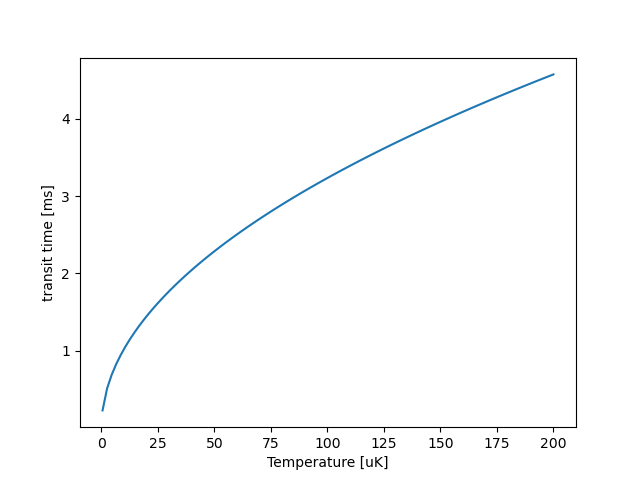

In [4]:
T_arr = np.linspace(.5, 200, 100)
v_t = np.linspace(.1, .3, 100)

t_t_arr = transitTime(T_arr, .1, 0.089)
plt.figure()
plt.plot(T_arr, t_t_arr*1000)
plt.xlabel("Temperature [uK]")
plt.ylabel("transit time [ms]")


/tmp/ipykernel_649641/2712036343.py:4: RuntimeWarning: invalid value encountered in sqrt
  t_f = (-v_i + np.sqrt(v_i**2 - 2*9.8*h))/-9.8


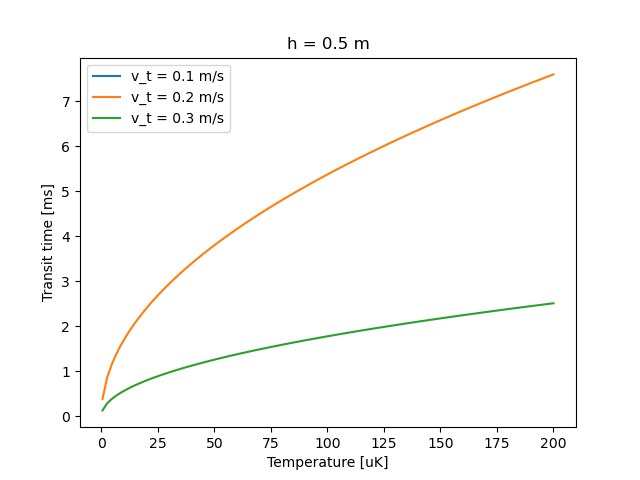

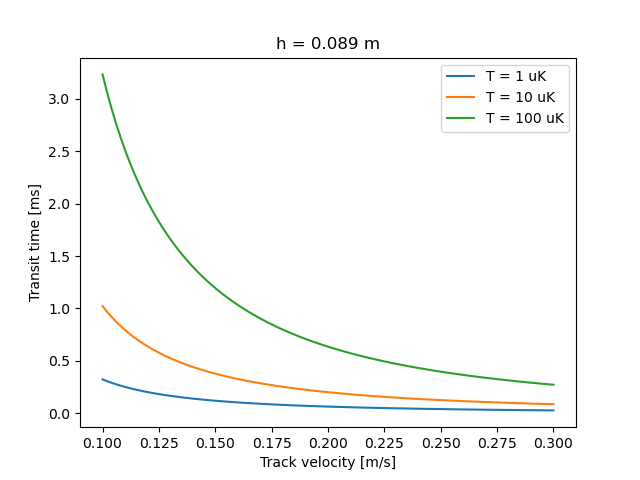

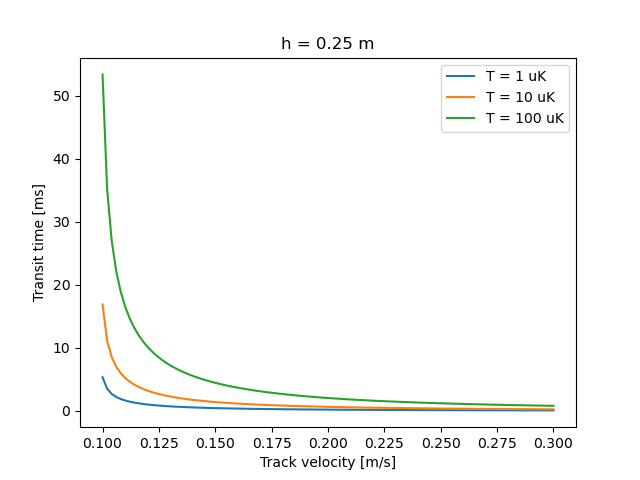

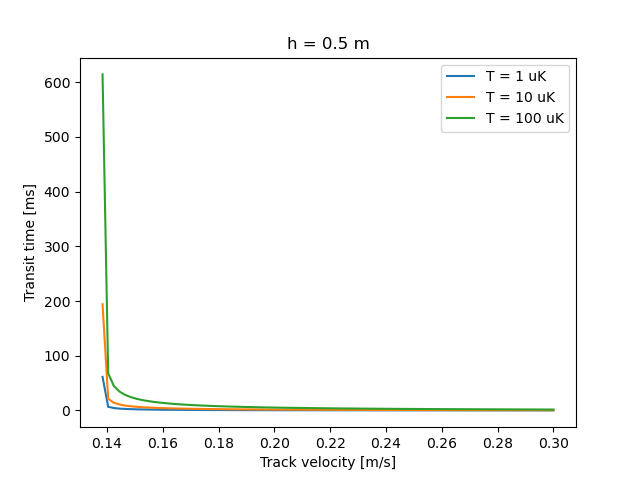

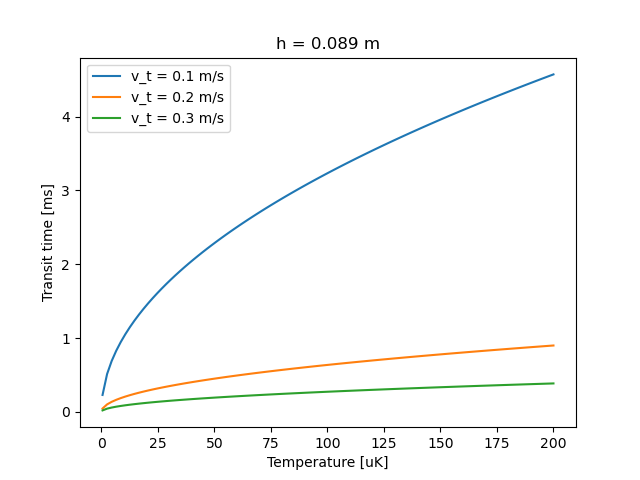

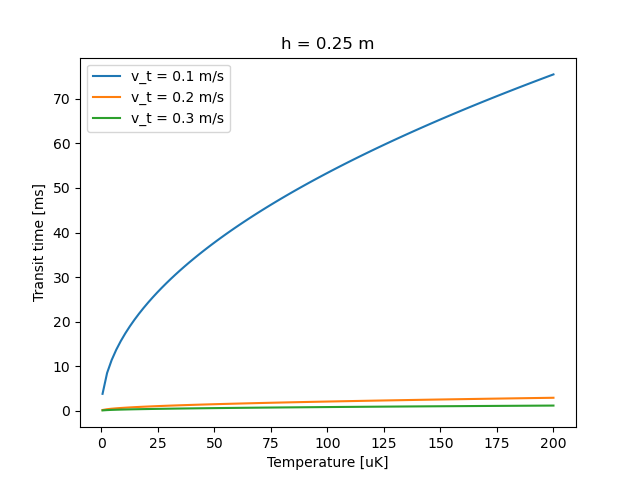

In [5]:
T_arr  = np.linspace(.5, 200, 100)
v_arr  = np.linspace(.1, .3, 100)
h_vals = [0.089, 0.25, 0.5]
T_vals = [1, 10, 100]
vt_vals = [0.1, 0.2, 0.3]

# transit time vs v_t, one line per T, one plot per h
for h in h_vals:
    plt.figure()
    for T in T_vals:
        plt.plot(v_arr, transitTime(T, v_arr, h)*1000, label=f"T = {T} uK")
    plt.xlabel("Track velocity [m/s]")
    plt.ylabel("Transit time [ms]")
    plt.title(f"h = {h} m")
    plt.legend()

# transit time vs T, one line per v_t, one plot per h
for h in h_vals:
    plt.figure()
    for vt in vt_vals:
        plt.plot(T_arr, transitTime(T_arr, vt, h)*1000, label=f"v_t = {vt} m/s")
    plt.xlabel("Temperature [uK]")
    plt.ylabel("Transit time [ms]")
    plt.title(f"h = {h} m")
    plt.legend()

plt.show()